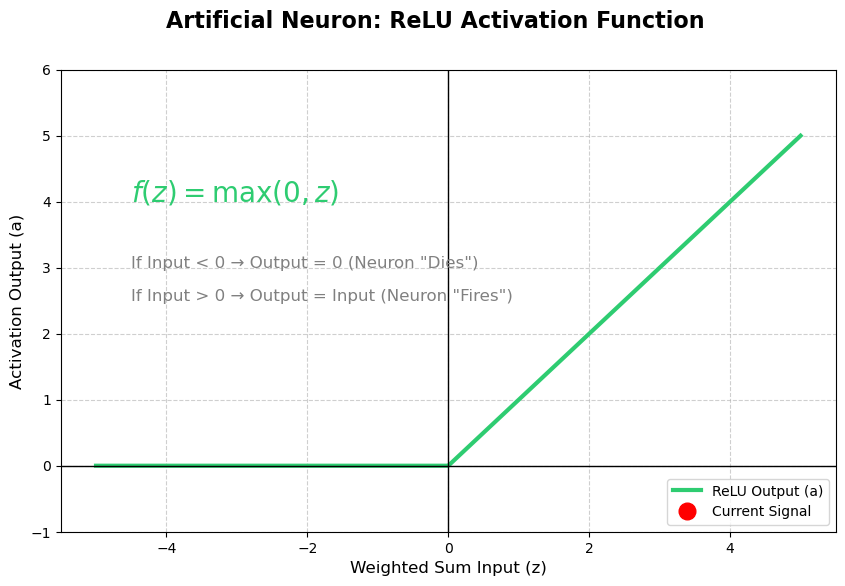

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

# --- 1. Define the Neuron Logic ---

def relu(x):
    """
    Rectified Linear Unit activation function.
    Returns 0 if x < 0, else returns x.
    """
    return np.maximum(0, x)

# --- 2. Setup the Data ---

# Generate a range of inputs (representing the weighted sum z = w*x + b)
# We go from negative to positive to show the "dead" zone and the active zone.
z_values = np.linspace(-5, 5, 500)
a_values = relu(z_values)

# --- 3. Setup the Visualization ---

fig, ax = plt.subplots(figsize=(10, 6))
fig.suptitle('Artificial Neuron: ReLU Activation Function', fontsize=16, fontweight='bold')

# Plot the ReLU curve
ax.plot(z_values, a_values, color='#2ecc71', linewidth=3, label='ReLU Output (a)')

# Add reference lines for the axes
ax.axhline(0, color='black', linewidth=1)
ax.axvline(0, color='black', linewidth=1)

# Add annotations to explain the math
ax.text(-4.5, 4, r'$f(z) = \max(0, z)$', fontsize=20, color='#2ecc71', fontweight='bold')
ax.text(-4.5, 3, 'If Input < 0 → Output = 0 (Neuron "Dies")', fontsize=12, color='gray')
ax.text(-4.5, 2.5, 'If Input > 0 → Output = Input (Neuron "Fires")', fontsize=12, color='gray')

# Set limits and labels
ax.set_xlim(-5.5, 5.5)
ax.set_ylim(-1, 6)
ax.set_xlabel('Weighted Sum Input (z)', fontsize=12)
ax.set_ylabel('Activation Output (a)', fontsize=12)
ax.grid(True, linestyle='--', alpha=0.6)

# Initialize elements for the animation (the moving dot and projection lines)
dot, = ax.plot([], [], 'ro', markersize=12, label='Current Signal')
v_line = ax.plot([], [], 'r--', linewidth=1, alpha=0.5)[0] # Vertical projection
h_line = ax.plot([], [], 'r--', linewidth=1, alpha=0.5)[0] # Horizontal projection
info_text = ax.text(0.02, 0.95, '', transform=ax.transAxes, fontsize=12, 
                    verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# --- 4. Animation Logic ---

def init():
    """Initialize the background of the animation."""
    dot.set_data([], [])
    v_line.set_data([], [])
    h_line.set_data([], [])
    info_text.set_text('')
    return dot, v_line, h_line, info_text

def update(frame):
    """Update the frame for the animation."""
    # Calculate current x position based on frame number
    # We oscillate back and forth to show the effect clearly
    t = np.linspace(-5, 5, 100)
    current_z = t[frame % len(t)]
    current_a = relu(current_z)
    
    # Update the dot position
    dot.set_data([current_z], [current_a])
    
    # Update vertical line (from x-axis to dot)
    v_line.set_data([current_z, current_z], [0, current_a])
    
    # Update horizontal line (from y-axis to dot)
    h_line.set_data([0, current_z], [current_a, current_a])
    
    # Update text info
    status = "FIRED" if current_z > 0 else "SUPPRESSED"
    color = "green" if current_z > 0 else "red"
    info_text.set_text(f'Input (z): {current_z:.2f}\nOutput (a): {current_a:.2f}\nStatus: {status}')
    info_text.get_bbox_patch().set_facecolor(color if current_z > 0 else 'lightgray')
    info_text.get_bbox_patch().set_alpha(0.3)
    
    return dot, v_line, h_line, info_text

# Create the animation
# interval=50 makes it move reasonably fast
ani = FuncAnimation(fig, update, frames=100, init_func=init, blit=True, interval=50, repeat=True)

plt.legend(loc='lower right')
plt.show()

# To save as a gif (requires pillow library):
ani.save('relu_neuron.gif', writer='pillow', fps=30)

FileNotFoundError: [Errno 2] No such file or directory: '/mnt/user-data/outputs/ntk_analogy.png'

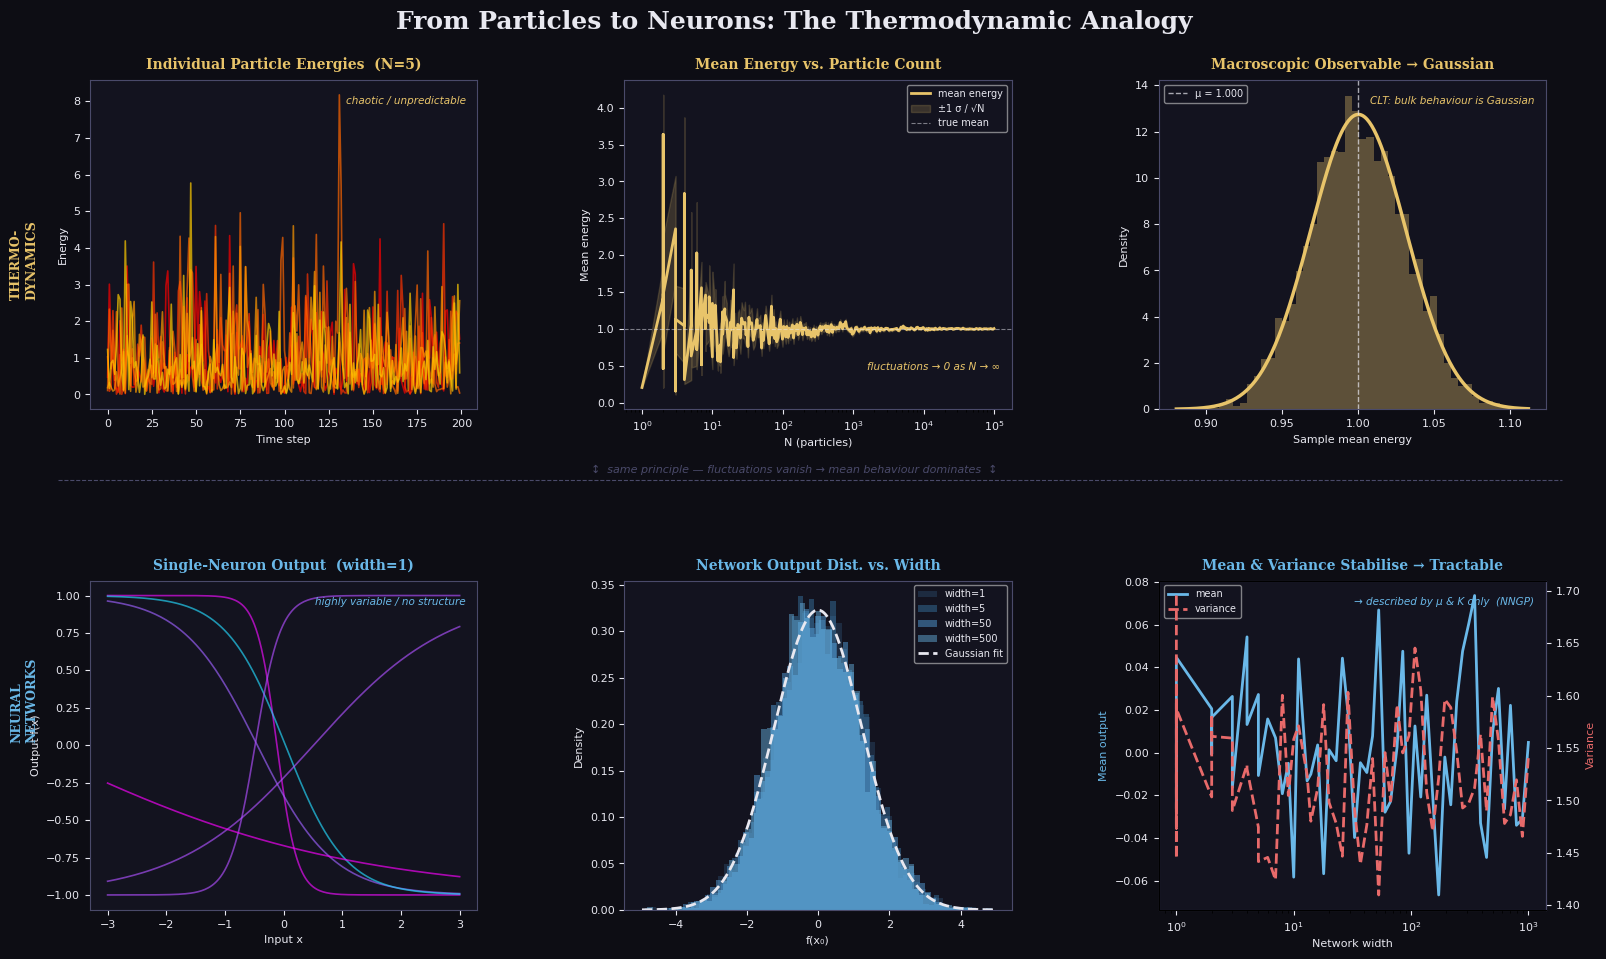

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyArrowPatch
from scipy.stats import norm

np.random.seed(42)

# ── Colour palette ──────────────────────────────────────────────────────────
BG      = "#0d0d14"
PANEL   = "#13131f"
ACCENT1 = "#e8c46a"   # gold   – thermodynamics
ACCENT2 = "#6ab8e8"   # blue   – neural networks
WHITE   = "#e8e8f0"
GREY    = "#4a4a6a"

fig = plt.figure(figsize=(16, 10), facecolor=BG)
fig.suptitle(
    "From Particles to Neurons: The Thermodynamic Analogy",
    fontsize=18, fontweight="bold", color=WHITE,
    fontfamily="serif", y=0.97
)

gs = gridspec.GridSpec(
    2, 3,
    figure=fig,
    hspace=0.52, wspace=0.38,
    left=0.06, right=0.97, top=0.90, bottom=0.07
)

def styled_ax(ax, title, accent):
    ax.set_facecolor(PANEL)
    for spine in ax.spines.values():
        spine.set_edgecolor(GREY)
    ax.tick_params(colors=WHITE, labelsize=8)
    ax.set_title(title, color=accent, fontsize=10,
                 fontweight="bold", pad=8, fontfamily="serif")
    return ax

# ════════════════════════════════════════════════════════════════════════════
# ROW 0 – THERMODYNAMICS
# ════════════════════════════════════════════════════════════════════════════

# ── [0,0]  Individual particle energies – chaotic ───────────────────────────
ax00 = styled_ax(fig.add_subplot(gs[0, 0]), "Individual Particle Energies  (N=5)", ACCENT1)
n_small = 5
energies_small = np.random.exponential(scale=1.0, size=(n_small, 200))
for i, e in enumerate(energies_small):
    ax00.plot(e, alpha=0.7, lw=1.2, color=plt.cm.autumn(i / n_small))
ax00.set_xlabel("Time step", color=WHITE, fontsize=8)
ax00.set_ylabel("Energy", color=WHITE, fontsize=8)
ax00.text(0.97, 0.95, "chaotic / unpredictable",
          transform=ax00.transAxes, ha="right", va="top",
          fontsize=7.5, color=ACCENT1, style="italic")

# ── [0,1]  Mean energy convergence ──────────────────────────────────────────
ax01 = styled_ax(fig.add_subplot(gs[0, 1]), "Mean Energy vs. Particle Count", ACCENT1)
ns = np.logspace(0.3, 5, 300).astype(int)
means, stds = [], []
for n in ns:
    samples = np.random.exponential(1.0, size=n)
    means.append(samples.mean())
    stds.append(samples.std() / np.sqrt(n))
means, stds = np.array(means), np.array(stds)
ax01.semilogx(ns, means, color=ACCENT1, lw=2, label="mean energy")
ax01.fill_between(ns, means - stds, means + stds,
                  color=ACCENT1, alpha=0.18, label="±1 σ / √N")
ax01.axhline(1.0, color=WHITE, lw=0.8, ls="--", alpha=0.5, label="true mean")
ax01.set_xlabel("N (particles)", color=WHITE, fontsize=8)
ax01.set_ylabel("Mean energy", color=WHITE, fontsize=8)
ax01.legend(fontsize=7, facecolor=PANEL, labelcolor=WHITE, framealpha=0.6)
ax01.text(0.97, 0.12, "fluctuations → 0 as N → ∞",
          transform=ax01.transAxes, ha="right", fontsize=7.5,
          color=ACCENT1, style="italic")

# ── [0,2]  Emergent Gaussian of macroscopic observable ──────────────────────
ax02 = styled_ax(fig.add_subplot(gs[0, 2]), "Macroscopic Observable → Gaussian", ACCENT1)
sample_means = [np.random.exponential(1.0, 1000).mean() for _ in range(3000)]
x = np.linspace(min(sample_means), max(sample_means), 300)
mu, sigma = np.mean(sample_means), np.std(sample_means)
ax02.hist(sample_means, bins=50, density=True,
          color=ACCENT1, alpha=0.35, edgecolor="none")
ax02.plot(x, norm.pdf(x, mu, sigma), color=ACCENT1, lw=2.5)
ax02.axvline(mu, color=WHITE, lw=1, ls="--", alpha=0.7, label=f"μ = {mu:.3f}")
ax02.set_xlabel("Sample mean energy", color=WHITE, fontsize=8)
ax02.set_ylabel("Density", color=WHITE, fontsize=8)
ax02.legend(fontsize=7, facecolor=PANEL, labelcolor=WHITE, framealpha=0.6)
ax02.text(0.97, 0.95, "CLT: bulk behaviour is Gaussian",
          transform=ax02.transAxes, ha="right", va="top",
          fontsize=7.5, color=ACCENT1, style="italic")

# ════════════════════════════════════════════════════════════════════════════
# ROW 1 – NEURAL NETWORKS
# ════════════════════════════════════════════════════════════════════════════

# ── [1,0]  Single neuron outputs – noisy ────────────────────────────────────
ax10 = styled_ax(fig.add_subplot(gs[1, 0]), "Single-Neuron Output  (width=1)", ACCENT2)
x_in = np.linspace(-3, 3, 200)
for _ in range(6):
    w = np.random.randn()
    b = np.random.randn()
    out = np.tanh(w * x_in + b)
    ax10.plot(x_in, out, alpha=0.65, lw=1.2,
              color=plt.cm.cool(np.random.rand()))
ax10.set_xlabel("Input x", color=WHITE, fontsize=8)
ax10.set_ylabel("Output f(x)", color=WHITE, fontsize=8)
ax10.text(0.97, 0.95, "highly variable / no structure",
          transform=ax10.transAxes, ha="right", va="top",
          fontsize=7.5, color=ACCENT2, style="italic")

# ── [1,1]  Output distribution converging to Gaussian ───────────────────────
ax11 = styled_ax(fig.add_subplot(gs[1, 1]), "Network Output Dist. vs. Width", ACCENT2)
widths = [1, 5, 50, 500 , 5000 , 50000]
x0 = np.array([1.0])
colors = ["#2a4a6a", "#3a7aaa", "#5aaae8", ACCENT2]
for w_size, col in zip(widths, colors):
    outputs = []
    for _ in range(4000):
        W1 = np.random.randn(w_size, 1) / np.sqrt(1)
        b1 = np.random.randn(w_size)
        W2 = np.random.randn(1, w_size) / np.sqrt(w_size)
        b2 = np.random.randn(1)
        h  = np.tanh(W1 @ x0 + b1)
        outputs.append((W2 @ h + b2)[0])
    ax11.hist(outputs, bins=60, density=True, alpha=0.45,
              color=col, edgecolor="none", label=f"width={w_size}")
# overlay Gaussian on widest
vals = []
for _ in range(4000):
    W1 = np.random.randn(500, 1) / np.sqrt(1)
    b1 = np.random.randn(500)
    W2 = np.random.randn(1, 500) / np.sqrt(500)
    b2 = np.random.randn(1)
    h  = np.tanh(W1 @ x0 + b1)
    vals.append((W2 @ h + b2)[0])
mu2, s2 = np.mean(vals), np.std(vals)
xr = np.linspace(mu2 - 4*s2, mu2 + 4*s2, 300)
ax11.plot(xr, norm.pdf(xr, mu2, s2), color=WHITE, lw=2, ls="--",
          label="Gaussian fit")
ax11.set_xlabel("f(x₀)", color=WHITE, fontsize=8)
ax11.set_ylabel("Density", color=WHITE, fontsize=8)
ax11.legend(fontsize=7, facecolor=PANEL, labelcolor=WHITE, framealpha=0.6)

# ── [1,2]  Mean & variance stabilise (≈ tractable) ──────────────────────────
ax12 = styled_ax(fig.add_subplot(gs[1, 2]), "Mean & Variance Stabilise → Tractable", ACCENT2)
width_range = np.logspace(0, 3, 60).astype(int)
run_means, run_vars = [], []
for w_size in width_range:
    outs = []
    for _ in range(1500):
        W1 = np.random.randn(w_size, 1) / np.sqrt(1)
        b1 = np.random.randn(w_size)
        W2 = np.random.randn(1, w_size) / np.sqrt(w_size)
        b2 = np.random.randn(1)
        h  = np.tanh(W1 @ x0 + b1)
        outs.append((W2 @ h + b2)[0])
    run_means.append(np.mean(outs))
    run_vars.append(np.var(outs))

ax12_r = ax12.twinx()
ax12.semilogx(width_range, run_means, color=ACCENT2, lw=2, label="mean")
ax12_r.semilogx(width_range, run_vars, color="#e86a6a", lw=2,
                ls="--", label="variance")
ax12.set_xlabel("Network width", color=WHITE, fontsize=8)
ax12.set_ylabel("Mean output", color=ACCENT2, fontsize=8)
ax12_r.set_ylabel("Variance", color="#e86a6a", fontsize=8)
ax12_r.tick_params(colors=WHITE, labelsize=8)
ax12_r.spines["right"].set_edgecolor(GREY)
lines1, labs1 = ax12.get_legend_handles_labels()
lines2, labs2 = ax12_r.get_legend_handles_labels()
ax12.legend(lines1 + lines2, labs1 + labs2,
            fontsize=7, facecolor=PANEL, labelcolor=WHITE, framealpha=0.6)
ax12.text(0.97, 0.95, "→ described by μ & K only  (NNGP)",
          transform=ax12.transAxes, ha="right", va="top",
          fontsize=7.5, color=ACCENT2, style="italic")

# ── Dividing line + labels ───────────────────────────────────────────────────
fig.text(0.01, 0.72, "THERMO-\nDYNAMICS", fontsize=9, color=ACCENT1,
         fontweight="bold", fontfamily="serif", va="center", rotation=90)
fig.text(0.01, 0.28, "NEURAL\nNETWORKS", fontsize=9, color=ACCENT2,
         fontweight="bold", fontfamily="serif", va="center", rotation=90)

# horizontal rule between rows
line = plt.Line2D([0.04, 0.98], [0.50, 0.50],
                  transform=fig.transFigure,
                  color=GREY, lw=0.8, ls="--")
fig.add_artist(line)

# analogy arrows + labels
fig.text(0.50, 0.505, "↕  same principle — fluctuations vanish → mean behaviour dominates  ↕",
         ha="center", va="bottom", fontsize=8, color=GREY, style="italic")

plt.savefig("/mnt/user-data/outputs/ntk_analogy.png",
            dpi=180, bbox_inches="tight", facecolor=BG)
print("Saved.")

Saved → ntk_single_point.gif


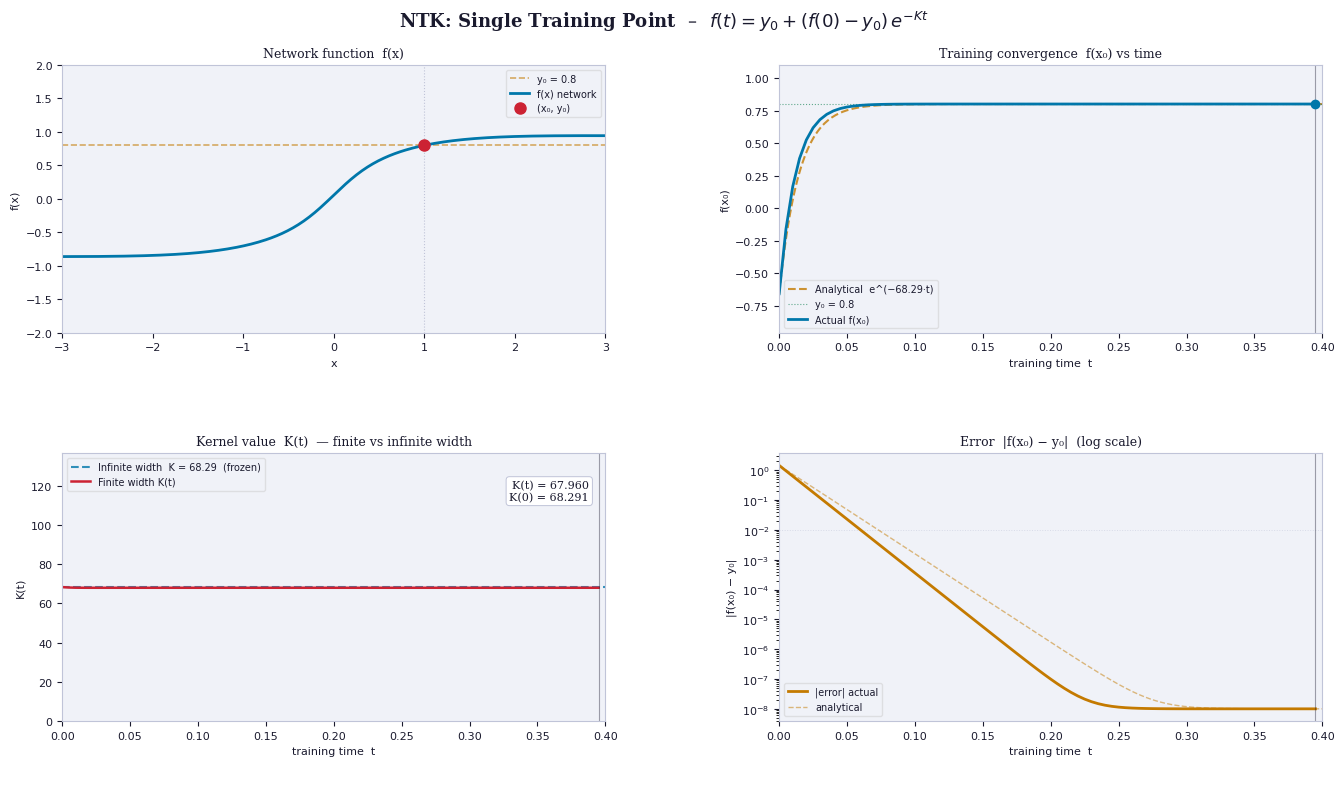

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.animation import FuncAnimation, PillowWriter
from matplotlib.colors import LinearSegmentedColormap

np.random.seed(42)

# ── Palette ───────────────────────────────────────────────────────────────────
BG    = "#FFFFFF"
PANEL = "#f0f2f8"
WHITE = "#1a1a2e"   # text colour (dark on light)
GREY  = "#c0c4d8"
DIM   = "#8888aa"
GOLD  = "#c47a00"
CYAN  = "#0077aa"
RED   = "#cc2233"
GREEN = "#007744"

# ── Network ───────────────────────────────────────────────────────────────────
def init_params(width=64, depth=3):
    dims = [1] + [width]*(depth-1) + [1]
    return [(np.random.randn(d_out, d_in)/np.sqrt(d_in), np.zeros(d_out))
            for d_in, d_out in zip(dims[:-1], dims[1:])]

def forward_scalar(x, params):
    h = np.array([x])
    for i, (W, b) in enumerate(params):
        z = W @ h + b
        h = np.tanh(z) if i < len(params)-1 else z
    return h[0]

def forward_and_jac(x, params):
    h = np.array([x])
    acts, pres = [h], []
    for i, (W, b) in enumerate(params):
        z = W @ h + b; pres.append(z)
        h = np.tanh(z) if i < len(params)-1 else z
        acts.append(h)
    output = h[0]
    delta = np.array([1.0])
    grads = []
    for i in reversed(range(len(params))):
        W, _ = params[i]
        if i < len(params)-1:
            delta = delta * (1 - np.tanh(pres[i])**2)
        grads.append(delta.copy())
        grads.append(np.outer(delta, acts[i]))
        delta = W.T @ delta
    grads.reverse()
    return output, np.concatenate([g.ravel() for g in grads])

def compute_K(x, params):
    _, jac = forward_and_jac(x, params)
    return float(jac @ jac)

def train_step(params, x0, y0, lr=0.005):
    out, _ = forward_and_jac(x0, params)
    residual = out - y0
    h = np.array([x0]); acts=[h]; pres=[]
    for i, (W, b) in enumerate(params):
        z = W @ h + b; pres.append(z)
        h = np.tanh(z) if i < len(params)-1 else z
        acts.append(h)
    delta = np.array([residual])
    new_params = list(params)
    gps = [(np.zeros_like(W), np.zeros_like(b)) for W,b in params]
    for i in reversed(range(len(params))):
        W, _ = params[i]
        if i < len(params)-1:
            delta = delta * (1 - np.tanh(pres[i])**2)
        gW, gb = gps[i]
        gps[i] = (gW + np.outer(delta, acts[i]), gb + delta)
        delta = W.T @ delta
    return [(W - lr*gW, b - lr*gb) for (W,b),(gW,gb) in zip(params, gps)]

# ── Setup ─────────────────────────────────────────────────────────────────────
x0, y0 = 1.0, 0.8
params  = init_params(width=128)
f0      = forward_scalar(x0, params)
K       = compute_K(x0, params)          # frozen kernel

N_FRAMES = 80
LR       = 0.005
xs       = np.linspace(-3, 3, 300)

# pre-compute all frames
f_pred_history   = []   # f(x0) over time
K_history        = []
curve_history     = []   # full f(x) curve
params_cur = params
for frame in range(N_FRAMES):
    f_pred_history.append(forward_scalar(x0, params_cur))
    K_history.append(compute_K(x0, params_cur))
    curve_history.append([forward_scalar(x, params_cur) for x in xs])
    params_cur = train_step(params_cur, x0, y0, lr=LR)

# analytical trajectory
t_vals    = np.linspace(0, N_FRAMES*LR, 300)
f_analytic = y0 + (f0 - y0) * np.exp(-K * t_vals)

# ── Figure layout ─────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(14, 8), facecolor=BG)
fig.suptitle(
    r"NTK: Single Training Point  –  $f(t) = y_0 + (f(0)-y_0)\,e^{-Kt}$",
    fontsize=13, fontweight="bold", color=WHITE, fontfamily="serif", y=0.97
)

gs = gridspec.GridSpec(2, 2, figure=fig,
                       left=0.07, right=0.97,
                       top=0.90, bottom=0.08,
                       hspace=0.45, wspace=0.32)

def make_ax(subplot_spec, title):
    ax = fig.add_subplot(subplot_spec)
    ax.set_facecolor(PANEL)
    for sp in ax.spines.values(): sp.set_edgecolor(GREY)
    ax.tick_params(colors=WHITE, labelsize=8)
    ax.set_title(title, color=WHITE, fontsize=9, fontfamily="serif", pad=6)
    return ax

ax_net  = make_ax(gs[0, 0], "Network function  f(x)")
ax_conv = make_ax(gs[0, 1], "Training convergence  f(x₀) vs time")
ax_K    = make_ax(gs[1, 0], "Kernel value  K(t)  — finite vs infinite width")
ax_err  = make_ax(gs[1, 1], "Error  |f(x₀) − y₀|  (log scale)")

# ── Static elements ───────────────────────────────────────────────────────────
# ax_net
ax_net.axhline(y0, color=GOLD, lw=1.2, ls="--", alpha=0.6, label=f"y₀ = {y0}")
ax_net.axvline(x0, color=GREY, lw=0.8, ls=":")
ax_net.set_xlim(-3, 3); ax_net.set_ylim(-2, 2)
ax_net.set_xlabel("x", color=WHITE, fontsize=8)
ax_net.set_ylabel("f(x)", color=WHITE, fontsize=8)
ax_net.legend(fontsize=7, facecolor=PANEL, labelcolor=WHITE, framealpha=0.5)

# ax_conv
t_frames = np.arange(N_FRAMES) * LR
ax_conv.plot(t_vals, f_analytic, color=GOLD, lw=1.5, ls="--",
             label=f"Analytical  e^(−{K:.2f}·t)", alpha=0.8)
ax_conv.axhline(y0, color=GREEN, lw=0.8, ls=":", alpha=0.6, label=f"y₀ = {y0}")
ax_conv.set_xlim(0, N_FRAMES*LR); ax_conv.set_ylim(min(f0,y0)-0.3, max(f0,y0)+0.3)
ax_conv.set_xlabel("training time  t", color=WHITE, fontsize=8)
ax_conv.set_ylabel("f(x₀)", color=WHITE, fontsize=8)
ax_conv.legend(fontsize=7, facecolor=PANEL, labelcolor=WHITE, framealpha=0.5)

# ax_K
ax_K.axhline(K, color=CYAN, lw=1.5, ls="--", alpha=0.8,
             label=f"Infinite width  K = {K:.2f}  (frozen)")
ax_K.set_xlim(0, N_FRAMES*LR); ax_K.set_xlabel("training time  t", color=WHITE, fontsize=8)
ax_K.set_ylabel("K(t)", color=WHITE, fontsize=8)
ax_K.legend(fontsize=7, facecolor=PANEL, labelcolor=WHITE, framealpha=0.5)
ax_K.set_ylim(0, K*2)

# ax_err
ax_err.axhline(0.01, color=GREY, lw=0.7, ls=":", alpha=0.5)
ax_err.set_xlim(0, N_FRAMES*LR)
ax_err.set_xlabel("training time  t", color=WHITE, fontsize=8)
ax_err.set_ylabel("|f(x₀) − y₀|", color=WHITE, fontsize=8)
ax_err.set_yscale("log")

# ── Animated artists ──────────────────────────────────────────────────────────
curve_line,  = ax_net.plot([], [], color=CYAN, lw=2, label="f(x) network")
train_dot,   = ax_net.plot([], [], 'o', color=RED, ms=8, zorder=5, label="(x₀, y₀)")
ax_net.legend(fontsize=7, facecolor=PANEL, labelcolor=WHITE, framealpha=0.5)

conv_line,   = ax_conv.plot([], [], color=CYAN, lw=2, label="Actual f(x₀)")
conv_dot,    = ax_conv.plot([], [], 'o', color=CYAN, ms=6, zorder=5)
ax_conv.legend(fontsize=7, facecolor=PANEL, labelcolor=WHITE, framealpha=0.5)

K_line,      = ax_K.plot([], [], color=RED, lw=1.8, label="Finite width K(t)")
ax_K.legend(fontsize=7, facecolor=PANEL, labelcolor=WHITE, framealpha=0.5)

err_line,    = ax_err.plot([], [], color=GOLD, lw=2, label="|error| actual")
err_analytic,= ax_err.plot(t_vals,
                            np.abs((f0-y0)*np.exp(-K*t_vals)) + 1e-8,
                            color=GOLD, lw=1, ls="--", alpha=0.5, label="analytical")
ax_err.legend(fontsize=7, facecolor=PANEL, labelcolor=WHITE, framealpha=0.5)

# time indicator lines
t_vline_conv = ax_conv.axvline(0, color=WHITE, lw=0.8, alpha=0.4)
t_vline_K    = ax_K.axvline(0,    color=WHITE, lw=0.8, alpha=0.4)
t_vline_err  = ax_err.axvline(0,  color=WHITE, lw=0.8, alpha=0.4)

# K annotation box
K_text = ax_K.text(0.97, 0.90, "", transform=ax_K.transAxes,
                   ha="right", va="top", fontsize=8, color=WHITE,
                   fontfamily="serif",
                   bbox=dict(boxstyle="round,pad=0.3", fc=BG, ec=GREY, lw=0.7))

step_text = fig.text(0.50, 0.005, "", ha="center", fontsize=8,
                     color=DIM, fontfamily="serif")

def update(frame):
    t = frame * LR

    # network curve
    curve_line.set_data(xs, curve_history[frame])
    train_dot.set_data([x0], [y0])

    # convergence
    conv_line.set_data(t_frames[:frame+1], f_pred_history[:frame+1])
    conv_dot.set_data([t], [f_pred_history[frame]])

    # kernel
    K_line.set_data(t_frames[:frame+1], K_history[:frame+1])
    K_text.set_text(f"K(t) = {K_history[frame]:.3f}\nK(0) = {K:.3f}")

    # error
    errs = [abs(fp - y0) + 1e-8 for fp in f_pred_history[:frame+1]]
    err_line.set_data(t_frames[:frame+1], errs)

    # time markers
    for vl in (t_vline_conv, t_vline_K, t_vline_err):
        vl.set_xdata([t])

    step_text.set_text(f"step {frame+1}/{N_FRAMES}   |   t = {t:.3f}   |   "
                       f"f(x₀) = {f_pred_history[frame]:.4f}   |   "
                       f"error = {abs(f_pred_history[frame]-y0):.4f}")
    return (curve_line, train_dot, conv_line, conv_dot,
            K_line, err_line, t_vline_conv, t_vline_K, t_vline_err,
            K_text, step_text)

anim = FuncAnimation(fig, update, frames=N_FRAMES,
                     interval=80, blit=True)

writer = PillowWriter(fps=15)
out_path = "ntk_single_point.gif"
anim.save(out_path, writer=writer, dpi=120)
print(f"Saved → {out_path}")